In [1]:
import warnings
warnings.filterwarnings("ignore")

# Nonlinear Effects

Linear regression can model **nonlinear relationships** by adding powers of an input variable as new predictors.

### Example: Horsepower → MPG

A simple linear model assumes:

$$
MPG = \beta_0 + \beta_1 HP + \epsilon
$$

But the relationship between horsepower and MPG is curved, so we can add polynomial terms.

### Polynomial Regression

For a degree-$k$ polynomial:

$$
MPG = \beta_0 + \beta_1HP + \beta_2HP^2 + \cdots + \beta_kHP^k + \epsilon
$$

The important idea is that we treat the powers of $HP$ as **new input variables**:

$$
X = [HP,\ HP^2,\ HP^3,\ldots,HP^k]
$$

Then we can use the **same linear regression machinery** to estimate all the coefficients.

### Example: Quadratic Model

For $k=2$:

$$
MPG = \beta_0 + \beta_1HP + \beta_2HP^2 + \epsilon
$$

- $\beta_0$ → intercept
- $\beta_1$ → effect associated with $HP$
- $\beta_2$ → captures the curvature/nonlinear effect

### Key Idea

**Polynomial regression is still linear regression in the coefficients.**

The relationship with $HP$ is nonlinear, but the model is linear in $\beta_0,\beta_1,\beta_2,\ldots$.

### Statistical Significance

As before:

$$
t = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}
$$

If $|t| > 2$, there is commonly considered to be evidence that the corresponding predictor contributes to the model.

### Key Takeaways

- Add $HP^2, HP^3,\ldots$ to capture nonlinear relationships.
- Polynomial regression uses the **same linear regression machinery**.
- A quadratic model uses $HP$ and $HP^2$.
- The model is nonlinear in $HP$, but **linear in the coefficients**.
- Statistical significance of polynomial terms can be evaluated using t-statistics.

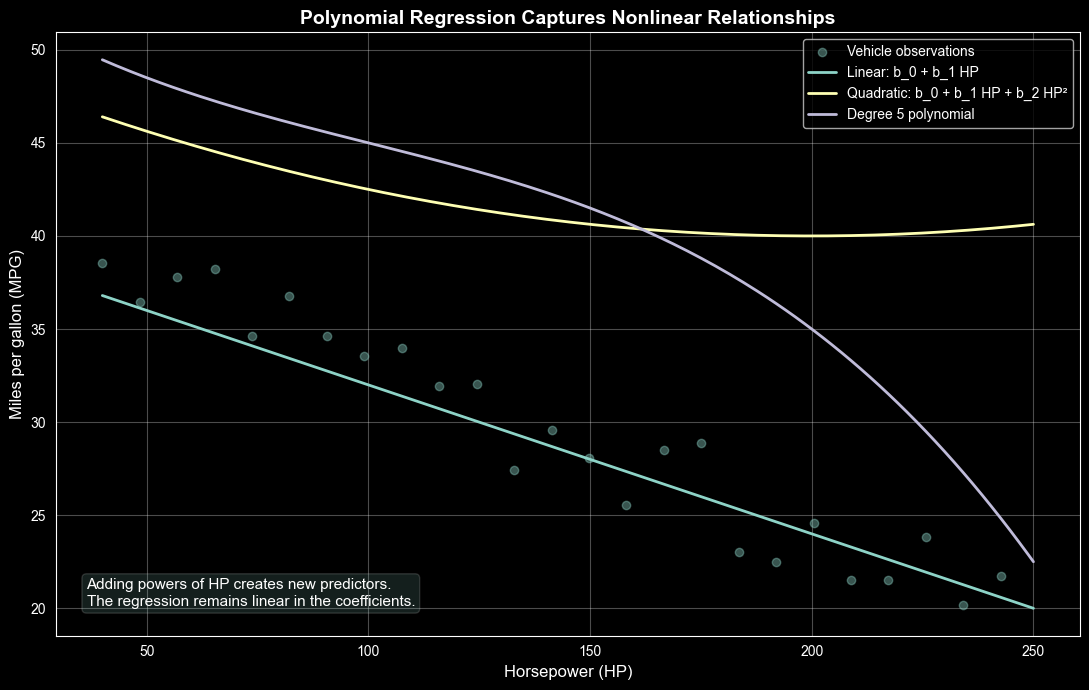

In [16]:
import numpy as np
import matplotlib.pyplot as plt

hp = np.linspace(40, 250, 200)

# Illustrative polynomial fits
linear = 40 - 0.08 * hp
quadratic = 50 - 0.10 * hp + 0.00025 * hp**2
degree5 = 55 - 0.18 * hp + 0.0012 * hp**2 - 0.000004 * hp**3

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(hp[::8], linear[::8] + np.random.normal(0, 2, len(hp[::8])),
           alpha=0.4, label="Vehicle observations")

ax.plot(hp, linear, linewidth=2, label="Linear: b_0 + b_1 HP")
ax.plot(hp, quadratic, linewidth=2, label="Quadratic: b_0 + b_1 HP + b_2 HP²")
ax.plot(hp, degree5, linewidth=2, label="Degree 5 polynomial")

ax.set_title(
    "Polynomial Regression Captures Nonlinear Relationships",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Horsepower (HP)", fontsize=12)
ax.set_ylabel("Miles per gallon (MPG)", fontsize=12)

ax.text(
    0.03, 0.05,
    "Adding powers of HP creates new predictors.\n"
    "The regression remains linear in the coefficients.",
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round", alpha=0.15)
)

ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Interaction Terms

## 1. Why Use Interaction Terms?

In a standard multiple linear regression model:

$$
Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \epsilon
$$

we assume that the effect of $X_1$ does **not depend on $X_2$**, and vice versa.

### Example: TV + Radio Advertising

Suppose we predict sales using:

- $TV$ = money spent on TV advertising
- $Radio$ = money spent on radio advertising

The model

$$
Sales = \beta_0 + \beta_1TV + \beta_2Radio + \epsilon
$$

assumes the effect of TV advertising is the same regardless of how much is spent on radio.

But this may not be realistic.

For example, radio advertising might make TV advertising more effective.

This is called an **interaction effect** or **synergy**.

---

## 2. Interaction Term

We can capture this effect by adding a new feature:

$$
TV \times Radio
$$

The model becomes:

$$
Sales =
\beta_0
+ \beta_1TV
+ \beta_2Radio
+ \beta_3(TV \times Radio)
+ \epsilon
$$

The interaction term is simply an additional predictor created by multiplying two existing predictors.

### Important idea

Although $TV \times Radio$ is nonlinear in the original variables, the model is still **linear in the coefficients**:

$$
\beta_0,\beta_1,\beta_2,\beta_3
$$

Therefore, we can still use ordinary linear regression.

---

## 3. What Does the Interaction Coefficient Mean?

The coefficient $\beta_3$ tells us whether the effect of one variable changes depending on the level of the other variable.

For example:

$$
Sales =
\beta_0
+ \beta_1TV
+ \beta_2Radio
+ \beta_3(TV \times Radio)
$$

The effect of TV is:

$$
\frac{\partial Sales}{\partial TV}
=
\beta_1 + \beta_3Radio
$$

So the effect of TV depends on how much is spent on radio.

Similarly:

$$
\frac{\partial Sales}{\partial Radio}
=
\beta_2 + \beta_3TV
$$

### Intuition

Without an interaction:

> "The effect of TV is always $\beta_1$."

With an interaction:

> "The effect of TV depends on how much radio advertising is being used."

---

## 4. Interaction Terms Are Still Linear Regression

Create a third feature:

$$
X_3 = TV \times Radio
$$

Then the model can simply be viewed as:

$$
Sales = \beta_0 + \beta_1X_1 + \beta_2X_2 + \beta_3X_3 + \epsilon
$$

where:

$$
X_1 = TV
$$

$$
X_2 = Radio
$$

$$
X_3 = TV \times Radio
$$

From the perspective of linear regression, there are simply **three input features**.

---

# 5. Hierarchy Principle

When an interaction term is included, we should also include the corresponding **main effects**.

For example, if the model contains:

$$
TV \times Radio
$$

it should also contain:

$$
TV
$$

and

$$
Radio
$$

So we use:

$$
Sales =
\beta_0
+ \beta_1TV
+ \beta_2Radio
+ \beta_3(TV \times Radio)
+ \epsilon
$$

### Why?

The interaction term is difficult to interpret without the main effects.

### Important

Even if the individual $TV$ or $Radio$ coefficients are not statistically significant, we generally **keep them** when their interaction is included.

This is the **hierarchy principle**.

---

# 6. Interaction Between Quantitative and Qualitative Variables

Interaction terms can also be used when one predictor is quantitative and another is qualitative.

### Example: Credit Card Balance

Suppose we predict credit card balance using:

- $Income$ = quantitative variable
- $Student$ = qualitative variable

Encode:

$$
Student =
\begin{cases}
1 & \text{if student}\\
0 & \text{if not a student}
\end{cases}
$$

---

## 7. Model Without an Interaction

Consider:

$$
Balance =
\beta_0
+ \beta_1Income
+ \beta_2Student
+ \epsilon
$$

### If the person is NOT a student

Since:

$$
Student = 0
$$

we get:

$$
Balance = \beta_0 + \beta_1Income
$$

So:

- Intercept = $\beta_0$
- Slope = $\beta_1$

### If the person IS a student

Since:

$$
Student = 1
$$

we get:

$$
Balance =
\beta_0 + \beta_1Income + \beta_2
$$

Rearranging:

$$
Balance =
(\beta_0+\beta_2)
+
\beta_1Income
$$

So:

- Intercept = $\beta_0+\beta_2$
- Slope = $\beta_1$

### Key result

The two regression lines have:

- **Different intercepts**
- **The same slope**

Therefore, the lines are **parallel**.

---

# 8. Model With an Interaction

Now add:

$$
Income \times Student
$$

The model becomes:

$$
Balance =
\beta_0
+ \beta_1Income
+ \beta_2Student
+ \beta_3(Income \times Student)
+ \epsilon
$$

Now the effect of income can depend on whether the person is a student.

---

## 9. Interpret the Two Cases

### Case 1: Not a student

If:

$$
Student = 0
$$

then:

$$
Income \times Student = 0
$$

So:

$$
Balance =
\beta_0+\beta_1Income
$$

Therefore:

- Intercept = $\beta_0$
- Slope = $\beta_1$

---

### Case 2: Student

If:

$$
Student = 1
$$

then:

$$
Income \times Student = Income
$$

Therefore:

$$
Balance =
\beta_0
+\beta_1Income
+\beta_2
+\beta_3Income
$$

Rearranging:

$$
Balance =
(\beta_0+\beta_2)
+
(\beta_1+\beta_3)Income
$$

Therefore:

- Intercept = $\beta_0+\beta_2$
- Slope = $\beta_1+\beta_3$

---

# 10. What Does $\beta_3$ Mean?

The interaction coefficient $\beta_3$ represents the **difference in slopes** between students and non-students.

Non-student slope:

$$
\beta_1
$$

Student slope:

$$
\beta_1+\beta_3
$$

Therefore:

$$
\text{Difference in slopes} = \beta_3
$$

### Intuition

Without the interaction:

> Student status changes the intercept, but not the relationship between income and balance.

With the interaction:

> Student status changes both the intercept **and** the relationship between income and balance.

---

# 11. Big Picture

### Without interaction

$$
Y = \beta_0+\beta_1X+\beta_2Z
$$

- $Z$ can shift the intercept
- The slope with respect to $X$ stays the same

### With interaction

$$
Y =
\beta_0+\beta_1X+\beta_2Z+\beta_3XZ
$$

- $Z$ can shift the intercept
- $Z$ can also change the slope of $X$

---

# Key Takeaways

- **Interaction terms allow the effect of one predictor to depend on another predictor.**
- An interaction is created by multiplying two predictors, such as $TV \times Radio$.
- Interaction models are still linear in the coefficients, so ordinary linear regression can be used.
- The **hierarchy principle** says that when an interaction is included, its corresponding main effects should also be included.
- With a quantitative × qualitative interaction, the interaction can change the **slope** between groups.
- Without an interaction, groups can have different intercepts but share the same slope; with an interaction, both intercepts and slopes can differ.

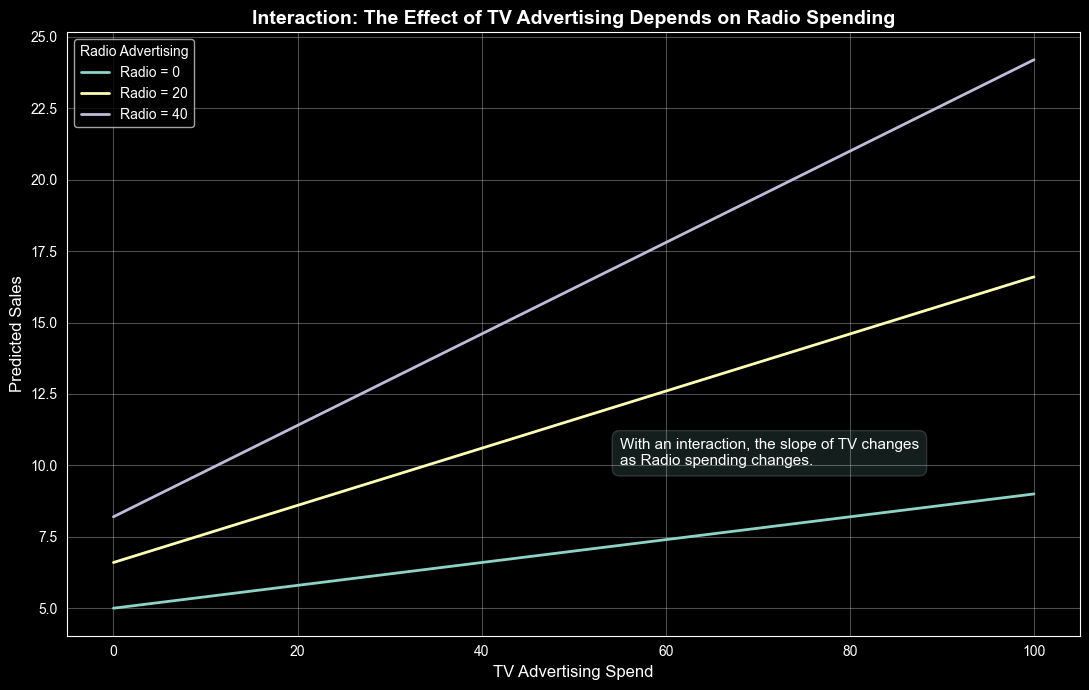

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Example coefficients
b_0 = 5
b_1 = 0.04
b_2 = 0.08
b_3 = 0.003

tv = np.linspace(0, 100, 100)

# Compare the effect of TV at different radio spending levels
radio_levels = [0, 20, 40]

plt.figure(figsize=(11, 7))

for radio in radio_levels:
    sales = b_0 + b_1 * tv + b_2 * radio + b_3 * tv * radio
    plt.plot(
        tv,
        sales,
        linewidth=2,
        label=f"Radio = {radio}"
    )

plt.title(
    "Interaction: The Effect of TV Advertising Depends on Radio Spending",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("TV Advertising Spend", fontsize=12)
plt.ylabel("Predicted Sales", fontsize=12)

plt.text(
    55, 10,
    "With an interaction, the slope of TV changes\n"
    "as Radio spending changes.",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", alpha=0.15)
)

plt.legend(title="Radio Advertising", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

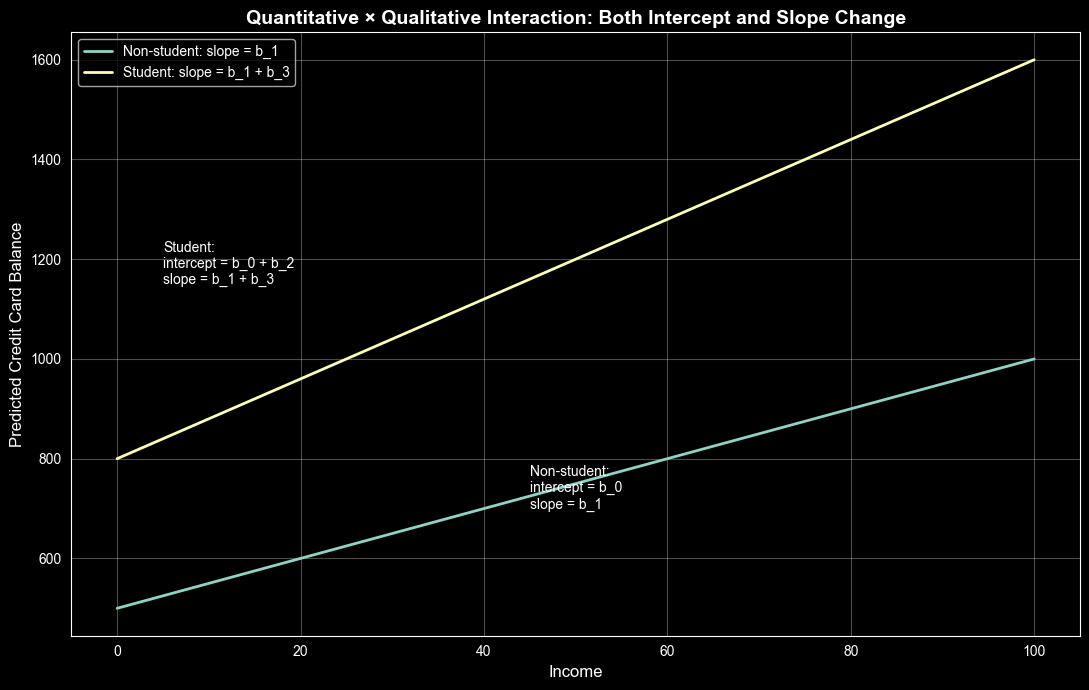

In [31]:
import numpy as np
import matplotlib.pyplot as plt

income = np.linspace(0, 100, 100)

# Example coefficients
b_0 = 500
b_1 = 5
b_2 = 300
b_3 = 3

# Non-student: Student = 0
balance_nonstudent = b_0 + b_1 * income

# Student: Student = 1
balance_student = (
    b_0
    + b_1 * income
    + b_2
    + b_3 * income
)

plt.figure(figsize=(11, 7))

plt.plot(
    income,
    balance_nonstudent,
    linewidth=2,
    label="Non-student: slope = b_1"
)

plt.plot(
    income,
    balance_student,
    linewidth=2,
    label="Student: slope = b_1 + b_3"
)

plt.title(
    "Quantitative × Qualitative Interaction: Both Intercept and Slope Change",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Income", fontsize=12)
plt.ylabel("Predicted Credit Card Balance", fontsize=12)

plt.text(
    45, 700,
    "Non-student:\nintercept = b_0\nslope = b_1",
    fontsize=10
)

plt.text(
    5, 1150,
    "Student:\nintercept = b_0 + b_2\nslope = b_1 + b_3",
    fontsize=10
)

plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()